In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Read csv
df = pd.read_csv('../data/processed/candor_dataset_clean_2.csv')

# H4: Objective timing metrics significantly predict perceived conversational skill.

How does the partner perceive the actor’s conversational skill?

Target: conversationalist_partner -> the partner’s evaluation of the actor

We include both actor and partner objective variables because conversational timing is dyadic. Perception depends on relative behavior, not just the actor’s behavior alone. Including both sides captures the full conversational dynamic and avoids bias.

## EDA

In [4]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
n = len(numeric_cols)

cols = 3
rows = int(np.ceil(n / cols))

"""plt.figure(figsize=(cols*5, rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True, bins=20, color="teal")
    plt.title(col)
    plt.tight_layout()

plt.show()
"""

'plt.figure(figsize=(cols*5, rows*4))\n\nfor i, col in enumerate(numeric_cols, 1):\n    plt.subplot(rows, cols, i)\n    sns.histplot(df[col], kde=True, bins=20, color="teal")\n    plt.title(col)\n    plt.tight_layout()\n\nplt.show()\n'

* speech_activity_actor: proportion of total conversation time during which the actor is speaking without overlapping with the partner.

* pauses_actor: proportion of total conversation time where actor is silent (not speaking and not overlapping). May reflect hesitations, listening, slow turn taking.

* overlap_actor: proportion of the total conversation time where actor is speaking simultaneously with the partner.

* tfo : time difference between when one speaker finishes their turn and when the next speaker begins theirs. It measures the temporal coordination of turn transitions in conversation. Positive: next speaker waits. Negative next speaker overlaps. FTO = sinchronized.

In [5]:
# Outliers
from scipy.stats import mstats
# limits=[0.05, 0.05] replace 5% bottom and top 5%
# only makes sense in conv length because the other variables have a predefined range (scale)
df['conv_length'] = mstats.winsorize(df['conv_length_actor'], limits=[0.05, 0.05])
df.drop(columns = ['conv_length_actor'], inplace = True)

### Correlations 
Correlations between objective and subjective variables and target ("conversationalist_partner")

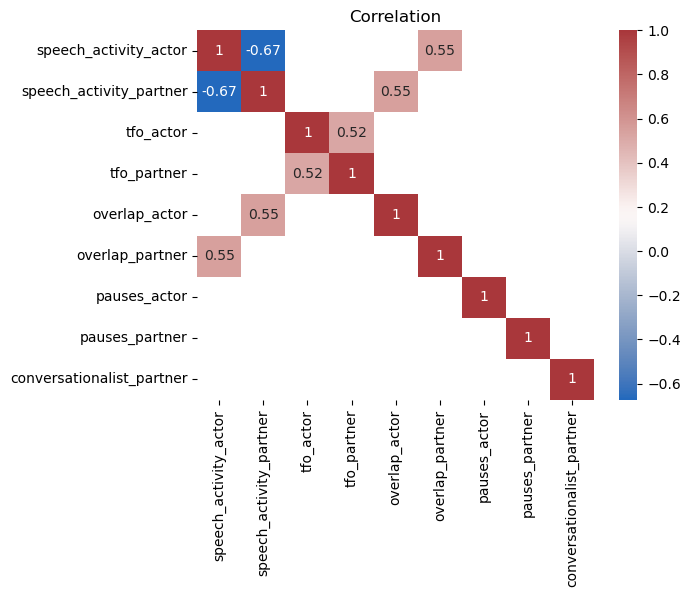

In [6]:
columns = ['speech_activity_actor',
       'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner', 'conversationalist_partner']
numeric_cols = df[columns].select_dtypes(include=['int64', 'float64']).columns

threshold = 0.5 
corr = df[numeric_cols].corr()
strong_corr = corr[(corr.abs() >= threshold)]
sns.heatmap(strong_corr, annot=True, cmap='vlag')
plt.title('Correlation')
plt.show()

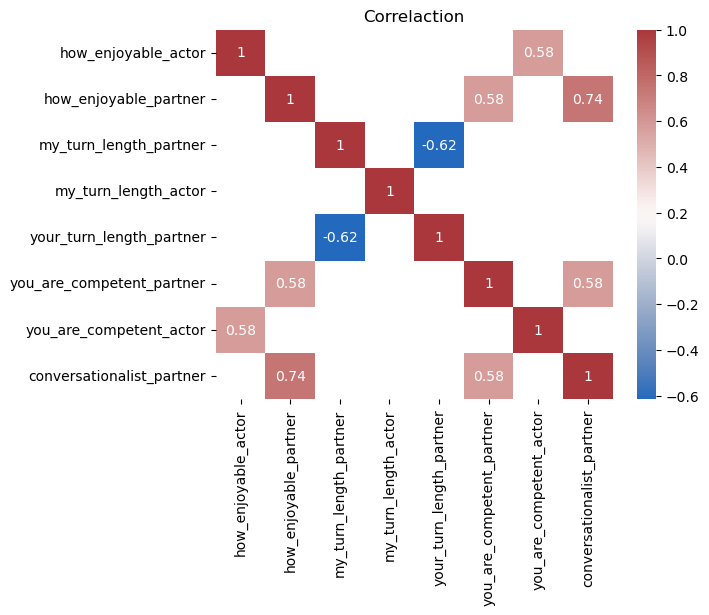

In [7]:
columns = ['how_enjoyable_actor', 'how_enjoyable_partner',
       'my_turn_length_partner', 'my_turn_length_actor',
       'your_turn_length_partner', 'you_are_competent_partner',
       'you_are_competent_actor',  'conversationalist_partner']
numeric_cols = df[columns].select_dtypes(include=['int64', 'float64']).columns

threshold = 0.5 
corr = df[numeric_cols].corr()
strong_corr = corr[(corr.abs() >= threshold)]
sns.heatmap(strong_corr, annot=True, cmap='vlag')
plt.title('Correlaction')
plt.show()

* In the conversationalist_partner row, timing variables show almost no correlation - don’t relate much to how skilled the partner thinks you are
* The correlation of 0.74 between how_enjoyable_partner and conversationalist_partner shows that when the partner enjoys the conversation, they automatically rate you as a good conversationalist, regardless of how long you talked or how your timing actually was.

In [8]:
# conversationalist_partner score ranges from 1 to 100, but the distribution is not uniform.
# small differences in raw score (eg 68 vs 70) are not meaningful.
# we convert the continuous score into three categories using terciles to avoid imbalance.
# conversation skill is based on perception better represented by classes than exact numbers.
terciles = df['conversationalist_partner'].quantile([0.33, 0.66]).values

def category(nota):
    if nota <= terciles[0]:
        return 0 
    elif nota <= terciles[1]:
        return 1 
    else:
        return 2 

df['target_class'] = df['conversationalist_partner'].apply(category)
print(df['target_class'].value_counts(normalize=True))


target_class
0    0.352500
1    0.342187
2    0.305312
Name: proportion, dtype: float64


## PCA

PCA was used to explore whether conversational skill has an underlying structure that can be captured by the variables in our dataset. It reduces high dimensional data into a small number of components that reveal patterns and separations.

* Do objective timing metrics naturally cluster conversations by skill level?

* Do subjective evaluations create a stronger structure than objective metrics?

* Which dimensions explain most of the variance in conversational skill?

### PCA only objective metrics

Purpose:
To test whether timing alone (pauses, FTO, overlap, balance, turn‑taking) explains conversational skill.

Justification:
Our hypotheses H1–H3 were specifically about timing and enjoyment, and H4 proposed that timing predicts conversational skill. Running PCA with only objective metrics isolates this question.

Expected outcome:
If timing truly predicts skill, we should see clear separation of skill levels in PCA space.

Actual outcome:
No separation -> timing does not structure conversational skill.

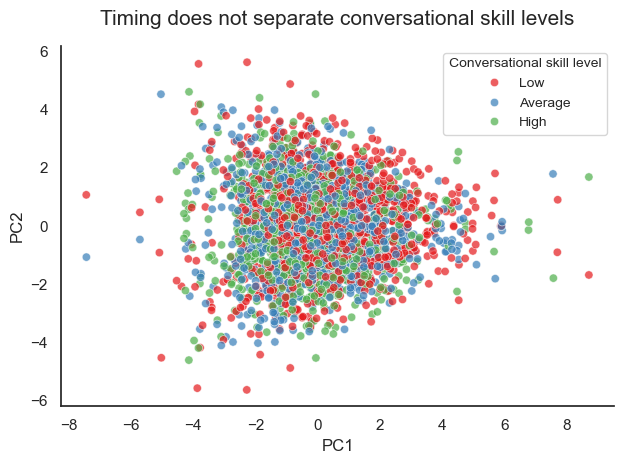

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
columns = ['call_id', 'actor_id', 'partner_id', 'speech_activity_actor',
       'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner',
       'conv_length', 'turn_overlap_gap_actor',
       'turn_overlap_gap_partner', 
       'target_class']

mapping = {0: 'Low', 1: 'Average', 2: 'High'}
df['skill_level'] = df['target_class'].map(mapping)

features = df[columns].select_dtypes(include=['float64', 'int64']).drop(columns=['target_class'])

X = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
components = pca.fit_transform(X)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]
df_shuffled = df.sample(frac=1, random_state=42)

sns.set_theme(style="white", palette=None) 
sns.scatterplot(
    data=df_shuffled,
    x="PC1",
    y="PC2",
    hue="skill_level",
    hue_order=['Low', 'Average', 'High'],
    palette="Set1",
    alpha=0.7
)
plt.legend(title="Conversational skill level", title_fontsize=10, fontsize=10, loc='upper right', frameon=True)
sns.despine(top=True, right=True)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("Timing does not separate conversational skill levels", fontsize=15, pad=15)
plt.tight_layout() 
plt.show()

### PCA objective metrics with subjective metrics

Purpose:
Test if adding subjective impressions (e.g., good listener, competence, enjoyment) begins to reveal structure.

Justification:
If structure emerges only after adding them, this indicates that skill is more perceptual than technical.

Outcome:
A separation can be seen by PC2, which is driven by subjective evaluations.

Interpretation:
Subjective impressions explain better the perceived conversational skill.

In [10]:
columns = ['speech_activity_actor',
       'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner',
       'how_enjoyable_actor', 'how_enjoyable_partner',
       'conversationalist_actor', 'conversationalist_partner',
       'my_turn_length_partner', 'my_turn_length_actor',
       'your_turn_length_partner', 'your_turn_length_actor',
       'conv_length_partner', 'turn_overlap_gap_actor',
       'turn_overlap_gap_partner', 'you_are_competent_partner',
       'you_are_competent_actor', 'i_am_good_listener_actor',
       'you_are_good_listener_actor', 'i_am_good_listener_partner',
       'you_are_good_listener_partner', 'conv_leader_partner',
       'conv_leader_actor', 'verbal_feedback_partner', 'verbal_feedback_actor',
       'nods_partner', 'nods_actor', 'conv_length', 'target_class']

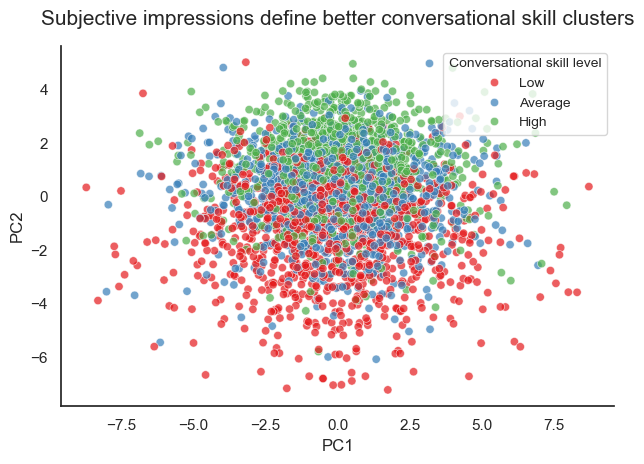

In [11]:
mapping = {0: 'Low', 1: 'Average', 2: 'High'}
df['skill_level'] = df['target_class'].map(mapping)

features = df[columns].select_dtypes(include=['float64', 'int64']).drop(columns=['target_class'])

X = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
components = pca.fit_transform(X)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]

sns.set_theme(style="white", palette=None) 
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="skill_level",
    hue_order=['Low', 'Average', 'High'],
    palette="Set1",
    alpha=0.7
)
plt.legend(title="Conversational skill level", title_fontsize=10, fontsize=10, loc='upper right', frameon=True)
sns.despine(top=True, right=True)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("Subjective impressions define better conversational skill clusters", fontsize=15, pad=15)
plt.tight_layout() 
plt.show()


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features.columns
)

loadings.sort_values(by='PC1', ascending=False).head(10)

,PC1,PC2
speech_activity_actor,0.342261,0.125438
your_turn_length_partner,0.301899,0.025521
my_turn_length_actor,0.295200,-0.000262
conv_leader_partner,0.232330,0.028474
nods_actor,0.209730,0.017781
verbal_feedback_actor,0.195915,0.022693
overlap_partner,0.192870,0.140103
i_am_good_listener_partner,0.121525,0.126053
you_are_good_listener_actor,0.098900,0.212061
turn_overlap_gap_actor,0.049174,-0.096310


### PCA all subjective metrics and objective metrics

Objective: Test the full multivariate structure of conversational skill using all reliable variables. 

* Variables with >2% missingness were excluded to avoid imputation bias, and artificial structure.
* Variables unrelated to conversational skill were excluded because they add noise.

Outcome:
The structure becomes even clearer: subjective variables dominate the main components while objective timing variables contribute very little.

Interpretation:
Conversational skill is a subjective.

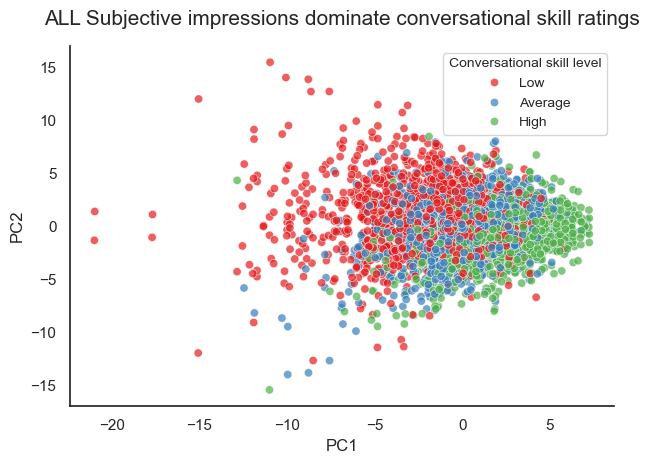

In [13]:
mapping = {0: 'Low', 1: 'Average', 2: 'High'}
df['skill_level'] = df['target_class'].map(mapping)

#
features = df.drop(columns = ['skill_level', 'conversationalist_partner', 'conversationalist_actor']).select_dtypes(include=['float64', 'int64']).drop(columns=['target_class'])

X = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
components = pca.fit_transform(X)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]

sns.set_theme(style="white", palette=None) 
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="skill_level",
    hue_order=['Low', 'Average', 'High'],
    palette="Set1",
    alpha=0.7
)
plt.legend(title="Conversational skill level", title_fontsize=10, fontsize=10, loc='upper right', frameon=True)
sns.despine(top=True, right=True)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("ALL Subjective impressions dominate conversational skill ratings", fontsize=15, pad=15)
plt.tight_layout() 
plt.show()


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features.columns
)

loadings.sort_values(by='PC1', ascending=False).head(10)

,PC1,PC2
PC2,0.231768,-0.000051
i_like_you_actor,0.180822,0.143516
you_are_friendly_actor,0.180666,0.134661
i_like_you_partner,0.180425,-0.143948
you_are_friendly_partner,0.180394,-0.135168
you_are_warm_actor,0.179781,0.140524
you_are_warm_partner,0.179502,-0.141030
you_are_kind_actor,0.178841,0.139249
you_are_kind_partner,0.178584,-0.139759
how_enjoyable_actor,0.176881,0.139735


### TSNE objective metrics

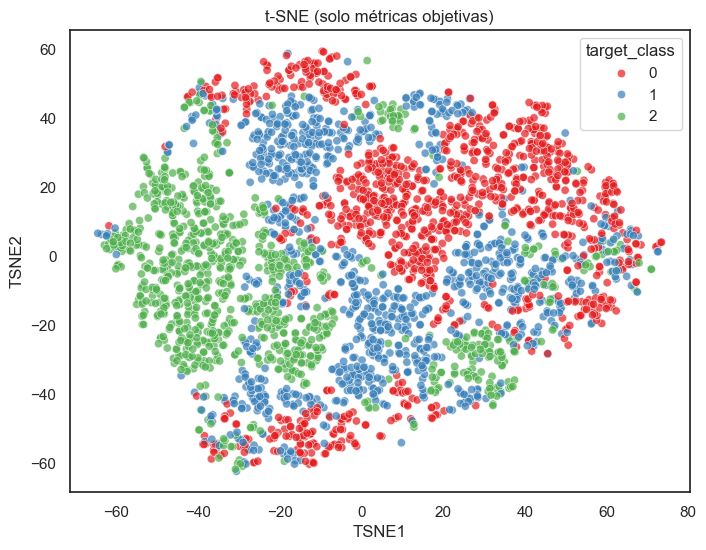

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

columns = ['speech_activity_actor',
       'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner',
       'conv_length', 'turn_overlap_gap_actor',
       'turn_overlap_gap_partner', 
       'target_class']
X = df[columns]
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_results = tsne.fit_transform(X_scaled)

df["TSNE1"] = tsne_results[:,0]
df["TSNE2"] = tsne_results[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="TSNE1",
    y="TSNE2",
    hue="target_class",
    palette="Set1",
    alpha=0.7
)
plt.title("t-SNE (solo métricas objetivas)")
plt.show()


## Are these metrics enough to predict classification?

 We trained three Random Forest classifiers using the same three feature sets. This allowed us to test whether the structure revealed by PCA translates into actual predictive performance.

### Random Forest only objective metrics

Performance is slightly above random chance (≈ 0.33 for 3 classes).

The model captures pattern (weak) from timing. Timing alone is not sufficient to classify conversational skill.

In [17]:
features = [
       'speech_activity_actor',
       'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner',
       'conv_length', 'turn_overlap_gap_actor',
       'turn_overlap_gap_partner']

X = df[features]
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rfc = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       226
           1       0.39      0.44      0.41       219
           2       0.51      0.44      0.48       195

    accuracy                           0.46       640
   macro avg       0.47      0.46      0.46       640
weighted avg       0.47      0.46      0.46       640



### Random Forest subjective metrics + objective metrics
Adding subjective variables improves perfomance: The medium class remains harder (“fuzzy” middle category).

In [18]:
features = [
 'speech_activity_actor','speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor',
       'overlap_partner', 'pauses_actor', 'pauses_partner',
       'how_enjoyable_actor', 'how_enjoyable_partner',
       'my_turn_length_partner', 'my_turn_length_actor',
       'your_turn_length_partner', 'your_turn_length_actor',
       'conv_length_partner', 'turn_overlap_gap_actor',
       'turn_overlap_gap_partner', 'you_are_competent_partner',
       'you_are_competent_actor', 'i_am_good_listener_actor',
       'you_are_good_listener_actor', 'i_am_good_listener_partner',
       'you_are_good_listener_partner', 'conv_leader_partner',
       'conv_leader_actor', 'verbal_feedback_partner', 'verbal_feedback_actor',
       'nods_partner', 'nods_actor', 'conv_length']

X = df[features]
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rfc = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.73      0.72       226
           1       0.52      0.47      0.49       219
           2       0.65      0.71      0.68       195

    accuracy                           0.63       640
   macro avg       0.63      0.64      0.63       640
weighted avg       0.63      0.63      0.63       640



### Random Forest ALL subjective metrics + objective metrics
When all relevant variables are included, the structure becomes clearer and more predictive

In [19]:
X = df.drop(columns = ['target_class', 'skill_level', 'PC1', 'PC2', 'call_id', 'actor_id', 'partner_id','conversationalist_actor',
       'conversationalist_partner'])
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rfc = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.69      0.75       226
           1       0.60      0.70      0.64       219
           2       0.82      0.80      0.81       195

    accuracy                           0.73       640
   macro avg       0.74      0.73      0.73       640
weighted avg       0.74      0.73      0.73       640

